<a href="https://colab.research.google.com/github/LeonardooAlves/WM9G1-BDAI/blob/main/Week%202/2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WM9G1 - BDAI - Logistic Regression


You will learn how to:
- Build an end-to-end **classification pipeline** (preprocessing → model → evaluation)
- Understand the **logistic regression algorithm** and interpret coefficients (odds ratios)
- Handle **imbalanced classes** using `class_weight='balanced'`
- Run **hyperparameter optimisation** using `GridSearchCV` over:

```python
'C': [0.01, 0.1, 1.0, 10],
'penalty': ['l1', 'l2']
```

---

## Scenario (Business framing)

We use a direct-marketing dataset from a bank (phone campaigns).  
**Goal:** predict whether a customer will subscribe to a term deposit (**yes/no**).

In business terms, this is a typical **propensity-to-buy / conversion prediction** problem.

## 1) Setup and Imports

We will use:
- **Pandas / NumPy** for data handling  
- **scikit-learn** for preprocessing, modelling, and evaluation  
- **matplotlib** for plots


In [1]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling & evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# Reproducibility
RANDOM_STATE = 42

from IPython.display import display


## 2) Load the Dataset in Google Colab

### Option A (recommended for teaching): upload the CSV file
If you have `banking.csv` locally, upload it here.

### Option B: download from an online source
If you don't have the file, you can modify the URL below to a known copy of the dataset.
(Some institutions keep a copy on the VLE / GitHub to ensure the link does not break.)


In [2]:
# The original notebook expects a file called 'banking.csv'
# If your uploaded file has a different name, update it here.
file_name = "banking.csv"
data = pd.read_csv(file_name)
print("Loaded:", data.shape)
data.head()

Loaded: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


## 3) Quick Data Check (What are we modelling?)

Before modelling, always confirm:
- Dataset size (rows/columns)
- Target column exists and has the expected values
- Missing values and obvious data issues


In [3]:
print("Shape:", data.shape)
print("\nColumns:", list(data.columns))

# Check missing values
missing = data.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 10):")
print(missing.head(10))

data.info()


Shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']

Missing values (top 10):
age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7 

Input variables

- age (numeric)
- job : type of job (categorical: “admin”, “blue-collar”, “entrepreneur”, “housemaid”, “management”, “retired”, “self-employed”, “services”, “student”, “technician”, “unemployed”, “unknown”)
- marital : marital status (categorical: “divorced”, “married”, “single”, “unknown”)
- education (categorical: “basic.4y”, “basic.6y”, “basic.9y”, “high.school”, “illiterate”, “professional.course”, “university.degree”, “unknown”)
- default: has credit in default? (categorical: “no”, “yes”, “unknown”)
- housing: has housing loan? (categorical: “no”, “yes”, “unknown”)
- loan: has personal loan? (categorical: “no”, “yes”, “unknown”)
- contact: contact communication type (categorical: “cellular”, “telephone”)
- month: last contact month of year (categorical: “jan”, “feb”, “mar”, …, “nov”, “dec”)
- day_of_week: last contact day of the week (categorical: “mon”, “tue”, “wed”, “thu”, “fri”)
- duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y=’no’). The duration is not known before a call is performed, also, after the end of the call, y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign (categorical: “failure”, “nonexistent”, “success”)
- emp.var.rate: employment variation rate — (numeric)
- cons.price.idx: consumer price index — (numeric)
- cons.conf.idx: consumer confidence index — (numeric)
- euribor3m: euribor 3 month rate — (numeric)
- nr.employed: number of employees — (numeric)

Predict variable (desired target):

y — has the client subscribed a term deposit? (binary: “1”, means “Yes”, “0” means “No”)

## 4) Target Variable and Class Imbalance

In this dataset, the target is typically:
- `y = 1` → subscribed to a term deposit
- `y = 0` → did not subscribe

Real business conversion datasets often have **few positives** (class imbalance).  
This matters because:
- A model can achieve high *accuracy* by predicting “no” for almost everyone.
- We therefore focus on metrics such as **recall**, **precision**, **F1**, and **ROC-AUC**.


Target distribution (counts):
 y
0    36548
1     4640
Name: count, dtype: int64

Target distribution (%):
 y
0    88.73
1    11.27
Name: count, dtype: float64


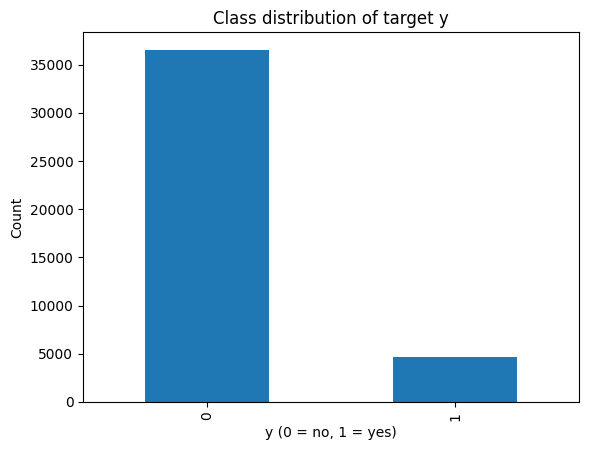

In [4]:
# If the response variable y is in the format: 'yes'/'no',
#use this code to map to 1/0
#if data["y"].dtype == "object":
#    data["y"] = data["y"].str.lower().map({"yes": 1, "no": 0})

# Basic distribution
counts = data["y"].value_counts(dropna=False)
print("Target distribution (counts):\n", counts)

pct = counts / counts.sum()
print("\nTarget distribution (%):\n", (pct * 100).round(2))

# Simple bar chart
plt.figure()
counts.sort_index().plot(kind="bar")
plt.title("Class distribution of target y")
plt.xlabel("y (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()

## 5) Light Preprocessing & EDA

The original dataset contains multiple “basic.*” education levels.
For a cleaner model (and simpler interpretation), we can group them together.

This step is not mandatory, but it shows a common practice:
**reduce sparsity** in categorical variables by merging similar categories.

In [5]:
#check it out
data["education"].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [6]:
# Only run this if the column exists
if "education" in data.columns:
    data["education"] = data["education"].replace(
        {"basic.4y": "Basic", "basic.6y": "Basic", "basic.9y": "Basic"}
    )
    print("Education categories after grouping:")
    print(data["education"].value_counts().head(10))
else:
    print("No 'education' column found — skipping this step.")


Education categories after grouping:
education
Basic                  12513
university.degree      12168
high.school             9515
professional.course     5243
unknown                 1731
illiterate                18
Name: count, dtype: int64


In [8]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_cols].groupby("y").mean()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


Observations:

- The average age of customers who bought the term deposit is higher than that of the customers who didn't.
- The pdays (days since the customer was last contacted) is understandably lower for the customers who bought it. The lower the pdays, the better the memory of the last call and hence the better chances of a sale.
- Surprisingly, campaigns (number of contacts or calls made during the current campaign) are lower for customers who bought the term deposit.

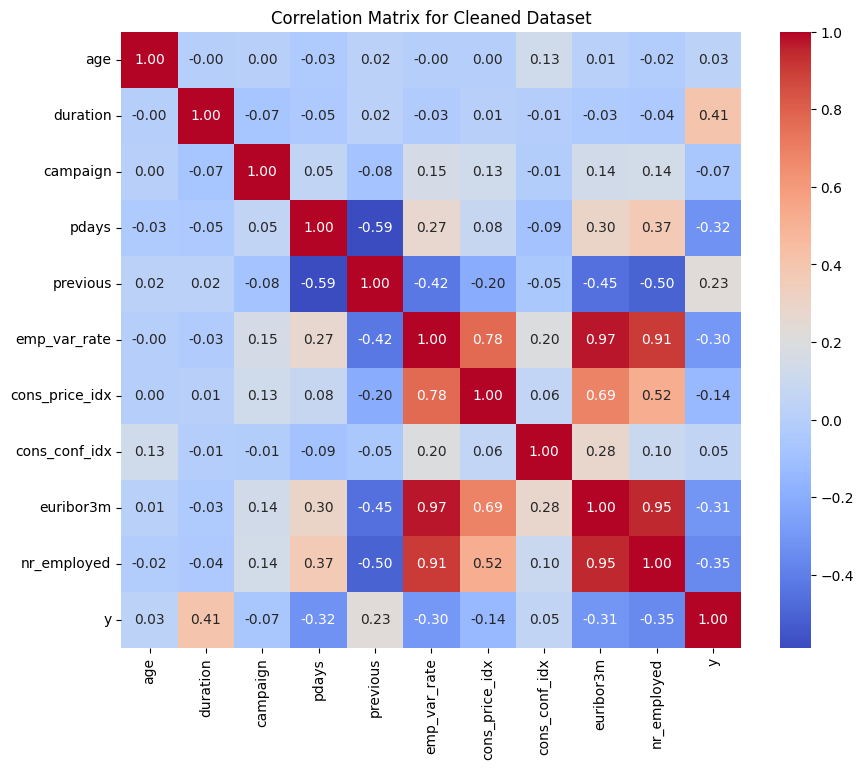

In [9]:
# Calculate the correlation matrix for dataset_cleaned
corr_matrix = data[numeric_cols].corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix for Cleaned Dataset')
plt.show()

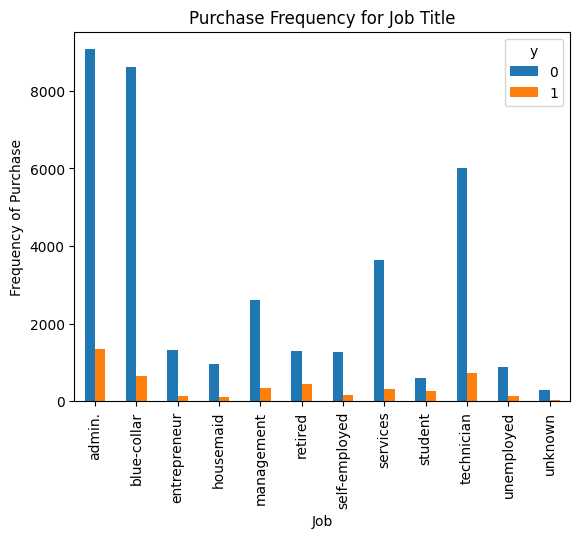

In [11]:
pd.crosstab(data.job,data.y).plot(kind='bar')
plt.title('Purchase Frequency for Job Title')
plt.xlabel('Job')
plt.ylabel('Frequency of Purchase')
plt.savefig('purchase_fre_job')

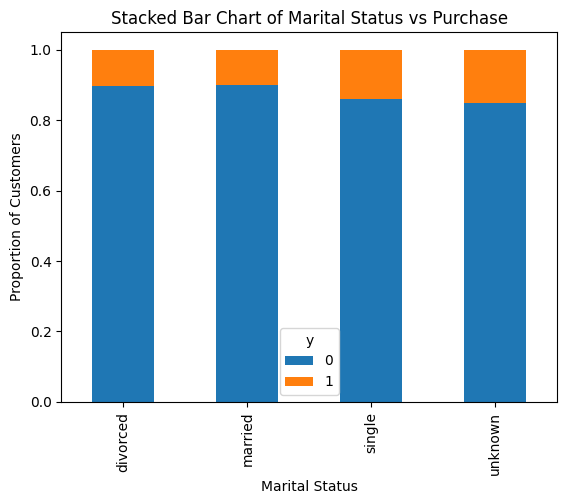

In [12]:
table=pd.crosstab(data.marital,data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Marital Status vs Purchase')
plt.xlabel('Marital Status')
plt.ylabel('Proportion of Customers')
plt.savefig('mariral_vs_pur_stack')

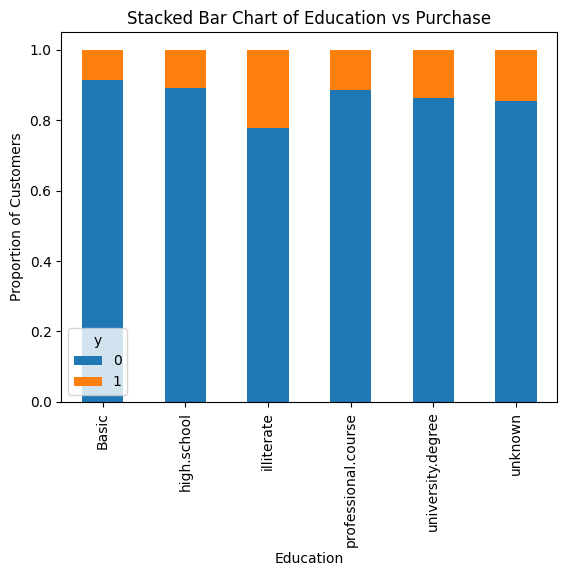

In [13]:
table=pd.crosstab(data.education,data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Education vs Purchase')
plt.xlabel('Education')
plt.ylabel('Proportion of Customers')
plt.savefig('edu_vs_pur_stack')

## 6) Train/Test Split

We split the dataset into:
- **Training set**: used to learn the model parameters
- **Test set**: held out for final evaluation

We use a **stratified split** to preserve the class imbalance ratio in both sets.


In [14]:
X = data.drop(columns=["y"])
y = data["y"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive  rate:", y_test.mean().round(4))


Train: (30891, 20)  Test: (10297, 20)
Train positive rate: 0.1127
Test positive  rate: 0.1127


## 7) Preprocessing Pipeline (One-Hot Encoding + Scaling)

Logistic regression is a linear model, so:
- **numeric variables** typically benefit from scaling
- **categorical variables** must be converted into numeric form

We use:
- `OneHotEncoder` for categorical columns
- `StandardScaler` for numeric columns

`ColumnTransformer` applies the right transformation to each column type.


In [15]:
# Identify categorical vs numeric columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)


Categorical columns: 10
Numeric columns: 10


## 8) Logistic Regression: what the algorithm does (conceptual)

Logistic Regression predicts the probability of the positive class:

$p(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$

where:
- \$\mathbf{x}\$ are the input features
- \$\mathbf{w}\$ are weights learned from the data
- \$b\$ is the intercept
- \$\sigma(z)=\frac{1}{1+e^{-z}}\$ is the **sigmoid** function

### Decision rule
By default:
- predict **1** if \$p \ge 0.5\$
- predict **0** otherwise

### Regularisation (why we tune `C` and `penalty`)
To avoid overfitting, Logistic Regression uses regularisation:
- `penalty='l2'`: shrinks weights smoothly (ridge-style)
- `penalty='l1'`: can set some weights to zero (feature selection)

`C` controls the **strength of regularisation**:
- smaller `C` → stronger regularisation (simpler model)
- larger `C` → weaker regularisation (more flexible model)


## 9) Baseline Model (no balancing)

We start with a standard logistic regression model.  
This gives us a baseline to compare against the balanced approach.


              precision    recall  f1-score   support

           0      0.930     0.975     0.952      9137
           1      0.678     0.422     0.520      1160

    accuracy                          0.912     10297
   macro avg      0.804     0.698     0.736     10297
weighted avg      0.902     0.912     0.903     10297

ROC-AUC: 0.9367


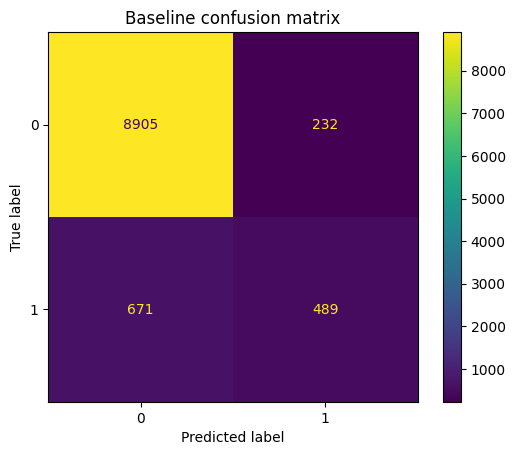

In [16]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="saga",      # supports both l1 and l2
        penalty="l2",
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba).round(4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Baseline confusion matrix")
plt.show()


## 10) Balanced Model (handling class imbalance)

A simple and effective approach is to tell the model that mistakes on the minority class are **more costly**:

- `class_weight='balanced'` automatically re-weights the classes inversely proportional to their frequency.

This often improves **recall** for the positive class (catching more “yes” customers),
sometimes at the cost of more false positives.


              precision    recall  f1-score   support

           0      0.983     0.858     0.916      9137
           1      0.441     0.881     0.588      1160

    accuracy                          0.861     10297
   macro avg      0.712     0.870     0.752     10297
weighted avg      0.922     0.861     0.879     10297

ROC-AUC: 0.9392


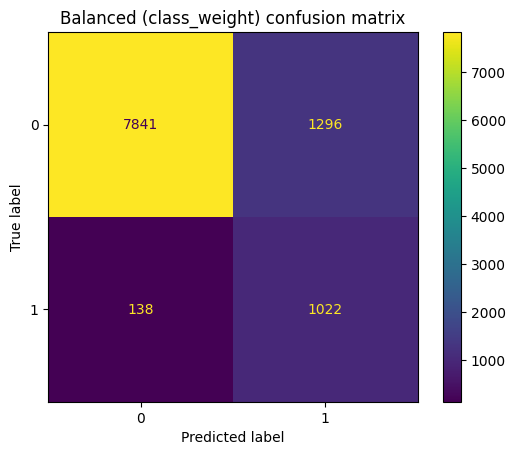

In [17]:
balanced_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

balanced_model.fit(X_train, y_train)

y_pred_b = balanced_model.predict(X_test)
y_proba_b = balanced_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_b, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_b).round(4))

cm_b = confusion_matrix(y_test, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b)
disp.plot()
plt.title("Balanced (class_weight) confusion matrix")
plt.show()


## 11) Hyperparameter Optimisation (Grid Search)

Now we tune the logistic regression hyperparameters using cross-validation.

We search over:
- `C ∈ [0.01, 0.1, 1.0, 10]`
- `penalty ∈ ['l1', 'l2']`

We keep `solver='saga'` because it supports both penalties.

### Choosing a scoring metric
For imbalanced problems, **F1** (harmonic mean of precision & recall) is often a good default.


In [ ]:
param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10],
    "clf__penalty": ["l1", "l2"],
}

tuned_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="saga",
        class_weight="balanced",   # keep balancing while tuning C/penalty
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

grid = GridSearchCV(
    estimator=tuned_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_.round(4))

### Inspect the grid search results

This table helps you explain **why** a particular combination was chosen.


In [ ]:
results = pd.DataFrame(grid.cv_results_)
cols = [
    "mean_test_score", "std_test_score",
    "param_clf__C", "param_clf__penalty",
    "rank_test_score"
]
results_view = results[cols].sort_values(["rank_test_score", "param_clf__C"])
results_view.head(10)


## 12) Evaluate the Best Model on the Test Set

After tuning, we evaluate on the held-out test set (never used in training or CV).


In [ ]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best).round(4))

cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp.plot()
plt.title("Best tuned model confusion matrix")
plt.show()


### ROC Curve (threshold behaviour)

The ROC curve shows the trade-off between:
- True Positive Rate (Recall)
- False Positive Rate

In business settings, you often choose a threshold based on campaign capacity and cost.


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (Best tuned model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.show()


## 13) Interpreting Coefficients (Odds Ratios)

A key advantage of logistic regression is interpretability.

For each feature:
- a **positive** coefficient increases the log-odds of subscribing
- a **negative** coefficient decreases the log-odds

If we exponentiate coefficients:
\$
\text{{odds ratio}} = e^{w}
\$

- odds ratio > 1 increases likelihood
- odds ratio < 1 decreases likelihood

Below we extract the most influential positive and negative features.


In [ ]:
# Get feature names after preprocessing
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols) if len(cat_cols) else np.array([])

feature_names = np.concatenate([
    np.array(num_cols, dtype=object),
    cat_feature_names.astype(object)
])

coefs = best_model.named_steps["clf"].coef_.ravel()
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": odds_ratios
}).sort_values("coef", ascending=False)

print("Top features increasing subscription probability:")
display(coef_df.head(10))

print("\nTop features decreasing subscription probability:")
display(coef_df.tail(10).sort_values("coef"))


---

# Short Exercise

Work individually or in pairs.

1. **Change the scoring metric** in `GridSearchCV` from `"f1"` to `"roc_auc"`.  
   - Does the best hyperparameter combination change?
   - Compare the resulting confusion matrix.

2. **Threshold tuning**: Instead of using the default threshold (0.5), try 0.3 and 0.7.  
   - How do precision and recall change?
   - Which threshold would you pick for a campaign with limited call-centre capacity?

3. (Optional) Add `class_weight` to the grid search:
   - `[None, 'balanced']`  
   Compare the results and explain which setting is better **and why**.
